In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import torch
import numpy as np

from dataset.dataset import Dataset
from utils.config import load_config
from utils.builder import build_trainer

# ResNet trained on female cohort

In [2]:
config_path = "../configs/resnet_f.yaml"

In [3]:
config = load_config(config_path)
data_path = "../"+config["data"]["data_path"]

torch.manual_seed(config["experiment"]["seed"])
np.random.seed(config["experiment"]["seed"])

dataset = Dataset(data_path, "G", config["data"]["batch_size"], use_tabular=config["data"]["use_tabular"], tabular_features=config["data"]["tabular_features"])
train_loader, val_loader, test_loader = dataset.get_loaders()

dataset_f = Dataset(data_path, "F", config["data"]["batch_size"])
_, val_loader_f, test_loader_f = dataset_f.get_loaders()

dataset_m = Dataset(data_path, "M", config["data"]["batch_size"])       
_, val_loader_m, test_loader_m = dataset_m.get_loaders()

In [4]:
trainer = build_trainer(config)
trainer.load_checkpoint()

## Testing with simillar threshold

In [5]:
best_thr = trainer.choose_threshold(val_loader)

/home/maryna/anaconda3/envs/compmed/lib/python3.9/site-packages/torch/nn/modules/conv.py:366: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1027.)
  return F.conv1d(


Best threshold: 0.581
Sensitivity: 0.901
Specificity: 0.839
AUC: 0.945
Accuracy: 0.868


In [6]:
print("\n===== ALL =====")
out = trainer.test(test_loader, best_thr)


===== ALL =====
           TEST RESULTS
  Threshold         : 0.581
  AUC               : 0.9480
  Accuracy          : 0.8711
  Sensitivity       : 0.8942  (recall on MI)
  Specificity       : 0.8456  (recall on NORM)
  Precision         : 0.8648
  F1 Score          : 0.8793
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     608        111
  True MI    :      84        710
              precision    recall  f1-score   support

        NORM       0.88      0.85      0.86       719
          MI       0.86      0.89      0.88       794

    accuracy                           0.87      1513
   macro avg       0.87      0.87      0.87      1513
weighted avg       0.87      0.87      0.87      1513



In [7]:
print("\n===== FEMALE =====")
out = trainer.test(test_loader_f, best_thr)


===== FEMALE =====
           TEST RESULTS
  Threshold         : 0.581
  AUC               : 0.9433
  Accuracy          : 0.8529
  Sensitivity       : 0.8902  (recall on MI)
  Specificity       : 0.8164  (recall on NORM)
  Precision         : 0.8257
  F1 Score          : 0.8567
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     289         65
  True MI    :      38        308
              precision    recall  f1-score   support

        NORM       0.88      0.82      0.85       354
          MI       0.83      0.89      0.86       346

    accuracy                           0.85       700
   macro avg       0.85      0.85      0.85       700
weighted avg       0.86      0.85      0.85       700



In [8]:
print("\n===== MALE =====")
out = trainer.test(test_loader_m, best_thr)


===== MALE =====
           TEST RESULTS
  Threshold         : 0.581
  AUC               : 0.9507
  Accuracy          : 0.8758
  Sensitivity       : 0.8848  (recall on MI)
  Specificity       : 0.8667  (recall on NORM)
  Precision         : 0.8699
  F1 Score          : 0.8773
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     351         54
  True MI    :      47        361
              precision    recall  f1-score   support

        NORM       0.88      0.87      0.87       405
          MI       0.87      0.88      0.88       408

    accuracy                           0.88       813
   macro avg       0.88      0.88      0.88       813
weighted avg       0.88      0.88      0.88       813



## Choosing best threshold separately for G, M and F

In [9]:
best_thr = trainer.choose_threshold(val_loader)

print("\n===== ALL =====")
out = trainer.test(test_loader, best_thr)

Best threshold: 0.503
Sensitivity: 0.909
Specificity: 0.821
AUC: 0.949
Accuracy: 0.863

===== ALL =====
           TEST RESULTS
  Threshold         : 0.503
  AUC               : 0.9421
  Accuracy          : 0.8434
  Sensitivity       : 0.8942  (recall on MI)
  Specificity       : 0.7951  (recall on NORM)
  Precision         : 0.8056
  F1 Score          : 0.8476
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     617        159
  True MI    :      78        659
              precision    recall  f1-score   support

        NORM       0.89      0.80      0.84       776
          MI       0.81      0.89      0.85       737

    accuracy                           0.84      1513
   macro avg       0.85      0.84      0.84      1513
weighted avg       0.85      0.84      0.84      1513



In [10]:
best_thr = trainer.choose_threshold(val_loader_f)

print("\n===== FEMALE =====")
out = trainer.test(test_loader_f, best_thr)

Best threshold: 0.459
Sensitivity: 0.903
Specificity: 0.811
AUC: 0.951
Accuracy: 0.850

===== FEMALE =====
           TEST RESULTS
  Threshold         : 0.459
  AUC               : 0.9450
  Accuracy          : 0.8343
  Sensitivity       : 0.9056  (recall on MI)
  Specificity       : 0.7673  (recall on NORM)
  Precision         : 0.7852
  F1 Score          : 0.8411
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     277         84
  True MI    :      32        307
              precision    recall  f1-score   support

        NORM       0.90      0.77      0.83       361
          MI       0.79      0.91      0.84       339

    accuracy                           0.83       700
   macro avg       0.84      0.84      0.83       700
weighted avg       0.84      0.83      0.83       700



In [11]:
best_thr = trainer.choose_threshold(val_loader_m)

print("\n===== MALE =====")
out = trainer.test(test_loader_m, best_thr)

Best threshold: 0.556
Sensitivity: 0.904
Specificity: 0.831
AUC: 0.941
Accuracy: 0.865

===== MALE =====
           TEST RESULTS
  Threshold         : 0.556
  AUC               : 0.9542
  Accuracy          : 0.8733
  Sensitivity       : 0.8883  (recall on MI)
  Specificity       : 0.8579  (recall on NORM)
  Precision         : 0.8652
  F1 Score          : 0.8766
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     344         57
  True MI    :      46        366
              precision    recall  f1-score   support

        NORM       0.88      0.86      0.87       401
          MI       0.87      0.89      0.88       412

    accuracy                           0.87       813
   macro avg       0.87      0.87      0.87       813
weighted avg       0.87      0.87      0.87       813



### ROC curves

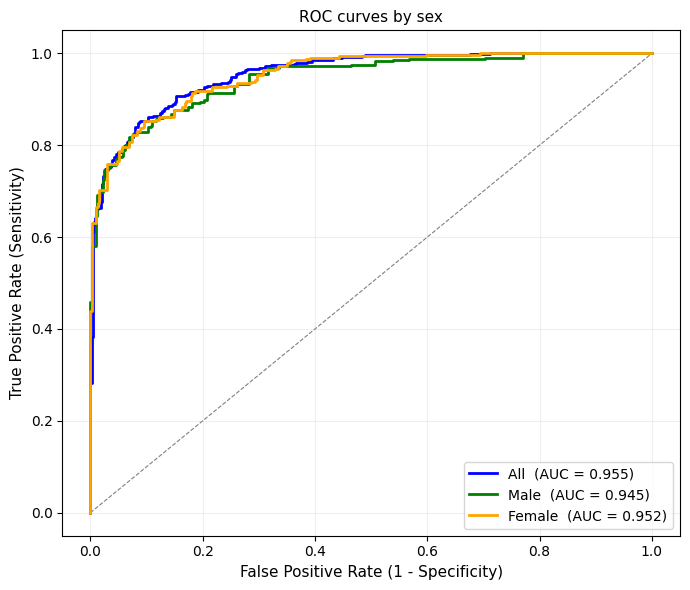

In [22]:
from utils.metrics import plot_roc_curves

plot_roc_curves(
    trainer,
    loaders_dict={
        'All':    test_loader,
        'Male':   test_loader_m,
        'Female': test_loader_f,
    }
)